In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV, train_test_split
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [2]:
path = "/home/scruffy/Documents/Career Foundry/specialization/Data Sets"

In [3]:
df = pd.read_pickle(os.path.join(path, 'Dataset_scaled_answers_clean.pkl'))

In [11]:
df = df.sort_values(['city','DATE'], ascending=[True,False])

In [12]:
df['pleasant_weather']=df['pleasant_weather'].shift(periods=1, fill_value=0)

In [13]:
#Create an 'X' matrix by dropping the unneeded columns.
X = df.drop(['DATE', 'MONTH','city','pleasant_weather'], axis=1)
y = df.pleasant_weather
print(X.shape)
print(y.shape)
X

(344250, 9)
(344250,)


,cloud_cover,global_radiation,humidity,precipitation,pressure,sunshine,temp_max,temp_mean,temp_min
344235,0.028626,0.017657,0.578825,-0.017328,0.192396,-0.419025,0.608058,0.452145,0.568409
344220,0.028626,0.017657,0.323155,-0.017328,0.316491,0.194088,0.808172,0.680398,0.793786
344205,-0.388128,0.017657,0.067485,-0.017328,0.414461,0.264832,0.945092,0.836572,0.992647
344190,0.445379,0.017657,0.131403,-0.017328,0.525494,0.099763,0.892430,0.836572,1.151736
344175,-1.638387,0.017657,0.259238,-0.017328,0.551619,0.642132,0.839769,0.740465,0.767271
...,...,...,...,...,...,...,...,...,...
74,-0.804881,-0.886600,0.323155,-0.424729,1.074125,0.170507,-0.529430,-0.484897,-0.346354
59,0.862132,-1.225696,0.706660,1.390058,0.133614,-1.173626,-0.297719,-0.280670,0.223716
44,0.862132,-1.184594,1.026248,-0.276583,-0.441143,-1.150045,-0.055476,0.091744,0.329775
29,0.862132,-1.102388,1.026248,1.130802,-1.022431,-1.008557,-0.139735,-0.100469,-0.001661


In [14]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
# creating a RF classifier
clf = RandomForestClassifier()

In [16]:
# Grid search cv
grid_space={'max_depth':[10,20,50],
              'n_estimators':[200,500],
              'max_features':[3,5,7]
           }

In [17]:
start = time.time()
grid = GridSearchCV(clf,param_grid=grid_space,cv=3,scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV 3/3] END max_depth=10, max_features=3, n_estimators=200;, score=0.873 total time= 6.3min
[CV 1/3] END max_depth=10, max_features=5, n_estimators=500;, score=0.873 total time=19.4min
[CV 3/3] END max_depth=20, max_features=3, n_estimators=200;, score=0.873 total time= 6.8min


/home/scruffy/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 2/3] END max_depth=10, max_features=5, n_estimators=200;, score=0.875 total time= 8.8min
[CV 3/3] END max_depth=10, max_features=5, n_estimators=500;, score=0.874 total time=18.4min
[CV 2/3] END max_depth=20, max_features=3, n_estimators=500;, score=0.874 total time=16.8min
[CV 3/3] END max_depth=20, max_features=7, n_estimators=200;, score=0.871 total time=11.3min
[CV 2/3] END max_depth=50, max_features=3, n_estimators=200;, score=0.872 total time= 6.1min
[CV 2/3] END max_depth=50, max_features=3, n_estimators=500;, score=0.872 total time=18.7min
[CV 1/3] END max_depth=10, max_features=5, n_estimators=200;, score=0.873 total time= 8.9min
[CV 1/3] END max_depth=10, max_features=7, n_estimators=200;, score=0.873 total time=10.9min
[CV 3/3] END max_depth=10, max_features=7, n_estimators=500;, score=0.874 total time=21.3min
[CV 3/3] END max_depth=20, max_features=5, n_estimators=500;, score=0.872 total time=21.3min
[CV 3/3] END max_depth=50, max_features=3, n_estimators=500;, score=0.

In [18]:
# grid search results
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': 10, 'max_features': 5, 'n_estimators': 200}
Best GRID search score is: 0.8738743645606392


In [19]:
# creating a RF classifier with the best results from above
clf2 = RandomForestClassifier(n_estimators = 200, max_depth=10, max_features=5, min_samples_leaf=1, criterion = 'entropy')  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf2.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, max_features=5,
                       n_estimators=200)

In [20]:
# performing predictions on the test dataset
y_pred = clf2.predict(X_test)
  
# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.8697893972403776


In [21]:
# creating a RF classifier with the best results from above
clf3 = RandomForestClassifier(n_estimators = 200, max_depth=10, max_features=5, min_samples_leaf=1, criterion = 'gini')  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features=5, n_estimators=200)

In [30]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

In [31]:
# performing predictions on the test dataset
y_pred = clf3.predict(X_test)

# Basic metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
    
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Confusion Matrix:
[[49816  4224]
 [ 4740 10070]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     54040
           1       0.70      0.68      0.69     14810

    accuracy                           0.87     68850
   macro avg       0.81      0.80      0.80     68850
weighted avg       0.87      0.87      0.87     68850

Model Accuracy:  0.8698039215686274


In [27]:
important = pd.Series(clf3.feature_importances_, index = X.columns) #.sort_values(ascending = False)
important

cloud_cover         0.028241
global_radiation    0.026746
humidity            0.017582
precipitation       0.108939
pressure            0.048844
sunshine            0.015255
temp_max            0.503978
temp_mean           0.168890
temp_min            0.081525
dtype: float64

Index(['cloud_cover', 'global_radiation', 'humidity', 'precipitation',
       'pressure', 'sunshine', 'temp_max', 'temp_mean', 'temp_min'],
      dtype='object')


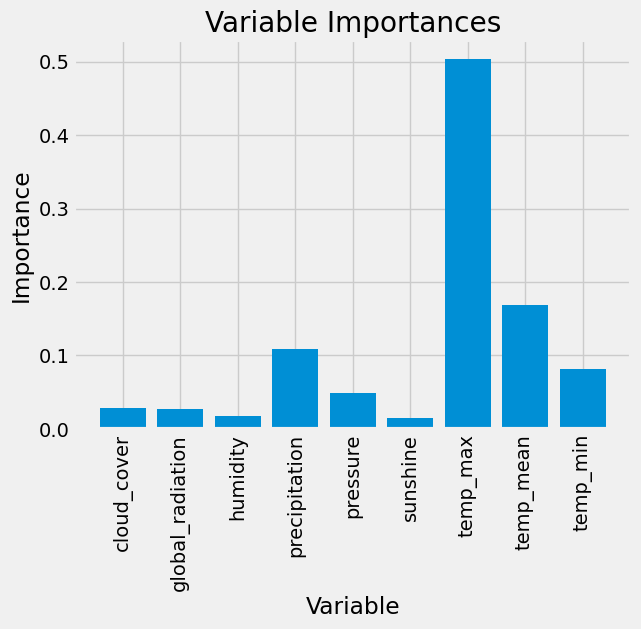

In [28]:
plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(important)))
print(X.columns)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, X.columns, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances')
plt.show()

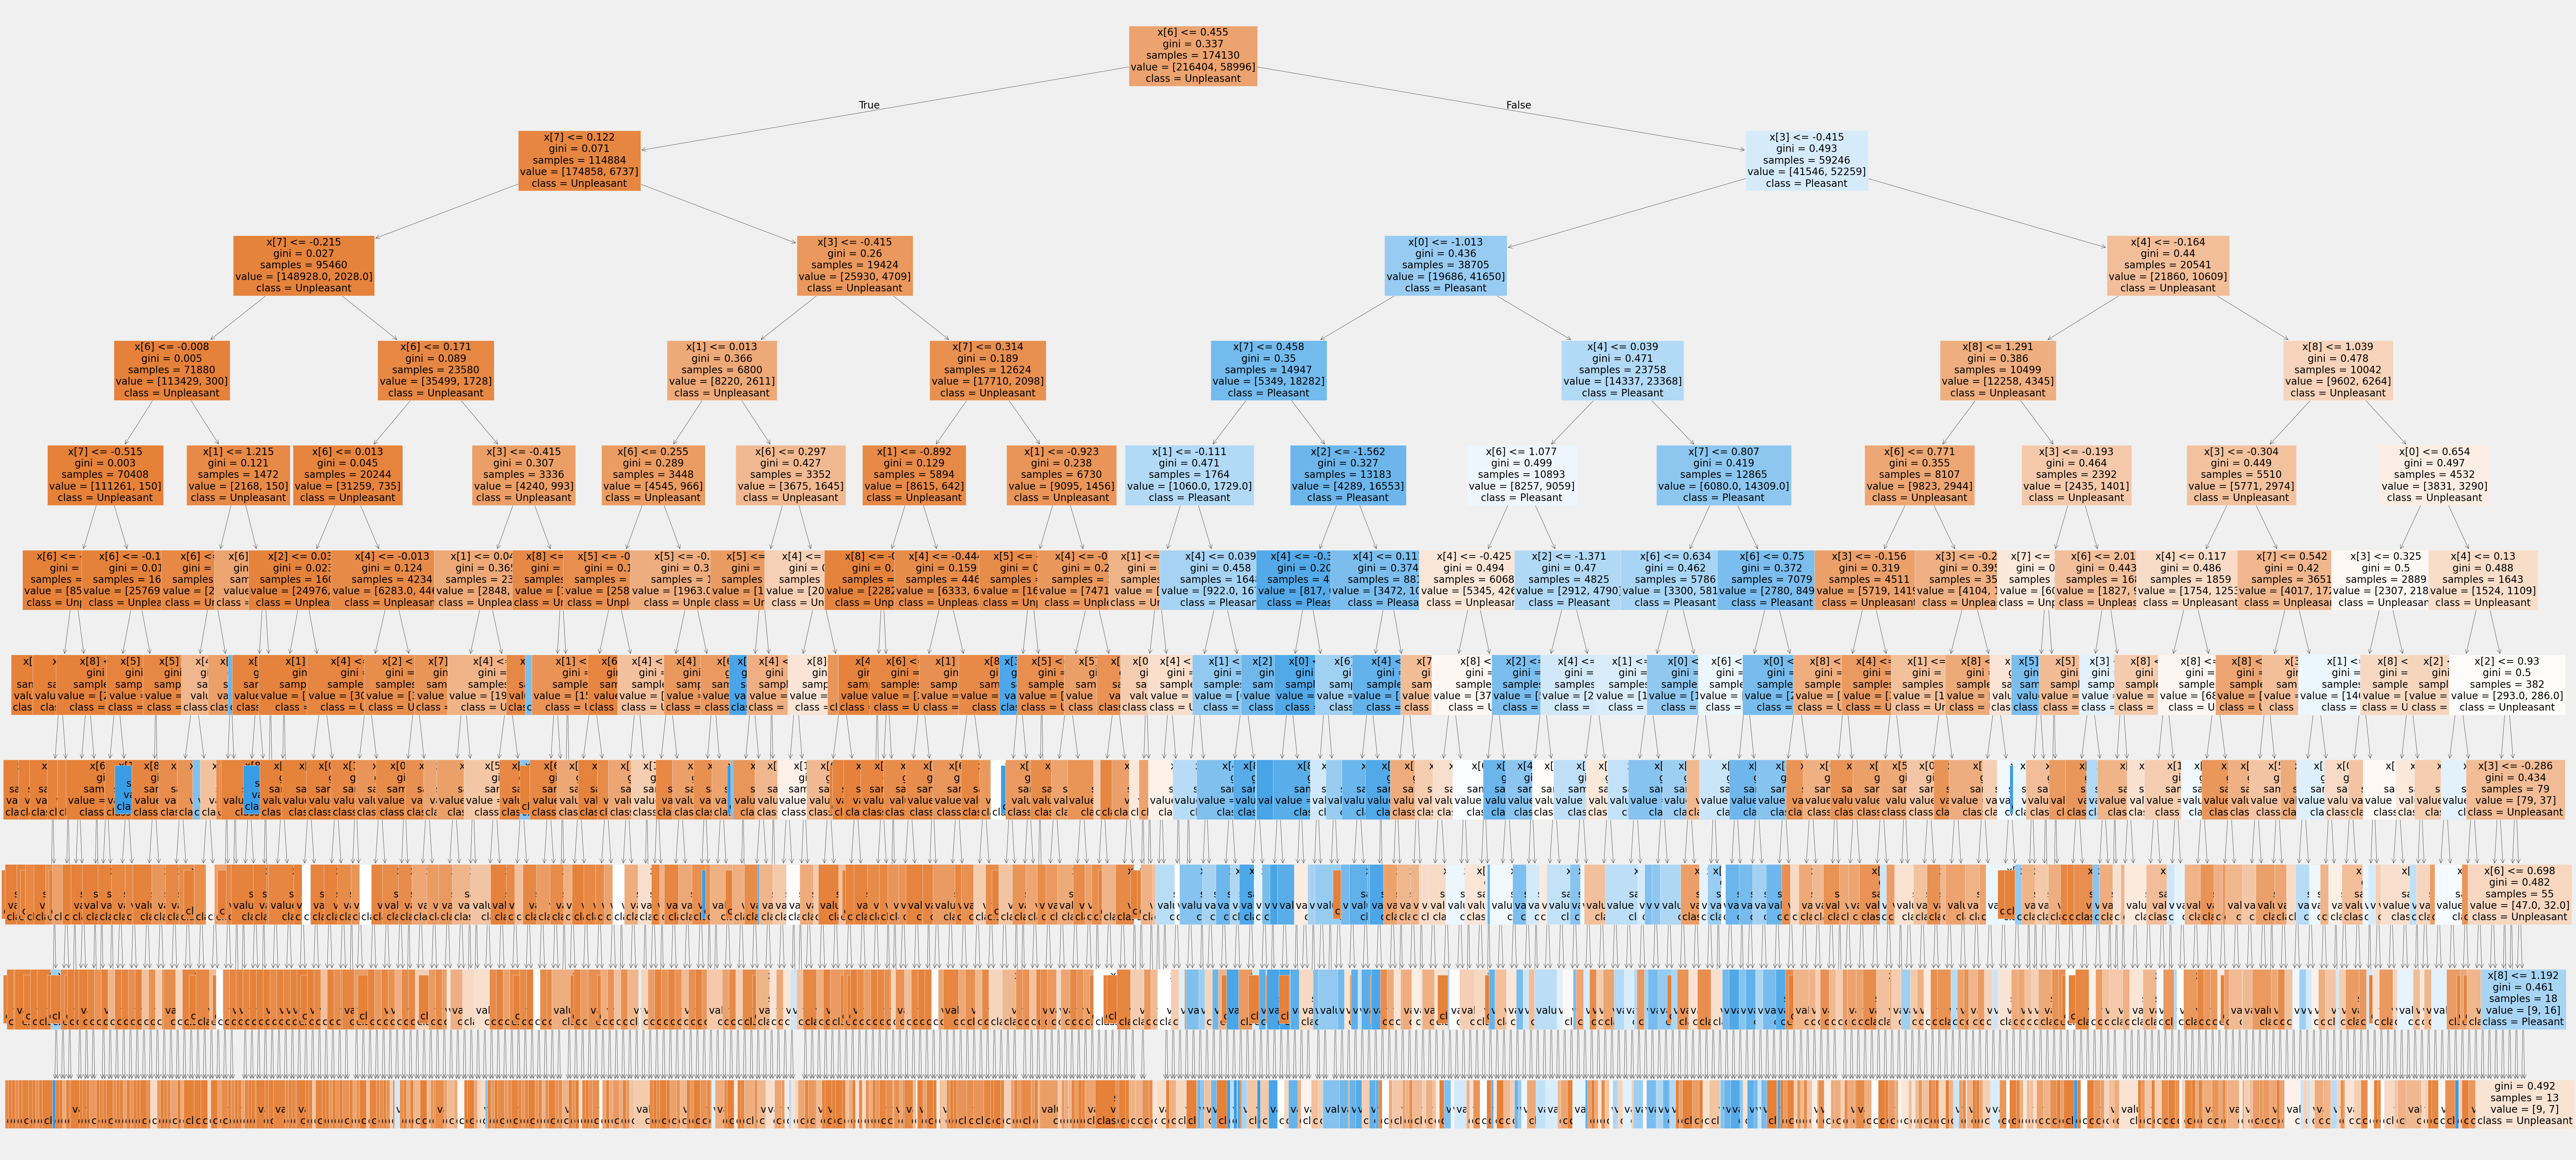

In [33]:
types = {0:'Unpleasant', 1:'Pleasant'}
fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, class_names=types, filled=True);

In [34]:
fig.savefig(f"{path}/RF_estimator15.png")

In [11]:
import operator
from sklearn.preprocessing import LabelEncoder
from numpy import unique
from numpy import reshape
from keras.models import Sequential
from keras.layers import Conv1D, Conv2D, Dense, Dropout, BatchNormalization, Flatten, MaxPooling1D, GlobalMaxPooling1D
from keras import utils
from keras.optimizers import Adam, Adamax
from keras.callbacks import EarlyStopping, ModelCheckpoint
from scikeras.wrappers import KerasClassifier
from math import floor
from sklearn.metrics import make_scorer, accuracy_score
from bayes_opt import BayesianOptimization
from sklearn.model_selection import StratifiedKFold
import gc
import time
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

In [12]:
path = "/home/scruffy/Documents/Career Foundry/specialization/Data Sets"

In [13]:
df = pd.read_pickle(os.path.join(path, 'Dataset_scaled_answers_clean.pkl'))

In [14]:
def create_weather_sequences_with_metadata(df, date_col='DATE', location_col='city', 
                                         feature_cols=None, sequence_length=6):
    """Convert tabular DataFrame to sequences for analysis with metadata tracking."""
    
    # Get feature columns
    if feature_cols is None:
        feature_cols = df.columns.drop([date_col, location_col, 'MONTH', 'pleasant_weather'])
    
    # Sort by location and date
    df_sorted = df.sort_values([location_col, date_col])
    
    # Create sequences for each location
    sequences = []
    targets = []
    metadata = []  # Track city and date for each sequence
    
    for location in df_sorted[location_col].unique():
        location_data = df_sorted[df_sorted[location_col] == location]
        features = location_data[feature_cols].values
        
        # Ensure target is AFTER the sequence
        for i in range(len(features) - sequence_length):
            sequences.append(features[i:i+sequence_length])  # t-6 to t-1
            targets.append(location_data.iloc[i+sequence_length]['pleasant_weather'])  # t
            metadata.append({
                'city': location,
                'date': location_data.iloc[i+sequence_length][date_col],
                'sequence_idx': len(sequences) - 1  # Index in the sequences array
            })
    
    return np.array(sequences), np.array(targets), metadata

In [15]:
# Create sequences with metadata
sequences, targets, metadata = create_weather_sequences_with_metadata(df, sequence_length=6)

In [16]:
# Create train/test split and preserve metadata
X_train, X_test, y_train, y_test, train_meta, test_meta = train_test_split(
    sequences, targets, metadata, 
    test_size=0.2, 
    random_state=42,
    stratify=targets
)

In [17]:
print(f"X_train shape: {X_train.shape}")

X_train shape: (275328, 6, 9)


In [18]:
len(X_train[0])

6

In [19]:
len(X_train[0][0])

9

In [20]:
y_train

array([0, 0, 0, ..., 0, 0, 0])

In [21]:
y_train.mean()

0.2150634879125988

In [22]:
from sklearn.utils.multiclass import type_of_target
type_of_target(y_train)

'binary'

In [23]:
timesteps = len(X_train[0])
input_dim = len(X_train[0][0])
n_classes = 2 #_count_classes(Y_train)
# Make scorer accuracy
score_acc = make_scorer(accuracy_score)

In [27]:
# Global constants
RANDOM_STATE = 42
MIN_ACCURACY = 0.3

In [3]:
def _force_cleanup():
    """Aggressive memory cleanup."""
    try:
        tf.keras.backend.clear_session()
        gc.collect()
    except Exception:
        pass

In [28]:
def bay_area(neurons, activation, kernel, optimizer, learning_rate, batch_size, epochs,
             layers1, layers2, normalization, dropout, dropout_rate): 
    
    # Parameter mappings
    optimizerL = ['Adam', 'Adamax']
    activationL = ['relu', 'sigmoid', 'softplus', 'tanh']
    
    # Parameter transformations
    neurons = max(8, min(128, round(neurons)))
    kernel = max(1, min(5, round(kernel)))
    activation = activationL[round(activation) % len(activationL)]
    optimizer_name = optimizerL[round(optimizer) % len(optimizerL)]
    batch_size = max(8, min(64, round(batch_size)))
    epochs = max(5, min(50, round(epochs)))
    layers1 = max(0, min(3, round(layers1)))  # Conv layers after first
    layers2 = max(1, min(3, round(layers2)))  # Dense layers
    
    def create_fresh_model():
        """Create a completely fresh model for each fold."""
        
        # Clear any existing session
        tf.keras.backend.clear_session()
        
        model = Sequential()
        
        # Get current data dimensions
        timesteps = X_train.shape[1]
        input_dim = X_train.shape[2]
        
        # Ensure kernel size is appropriate
        safe_kernel = min(kernel, timesteps)
        
        # First Conv1D layer
        model.add(Conv1D(
            filters=neurons, 
            kernel_size=safe_kernel,
            activation=activation, 
            input_shape=(timesteps, input_dim), 
            padding='same'
        ))
        
        # Batch normalization after first conv layer
        if normalization > 0.5:
            model.add(BatchNormalization())
        
        # Additional Conv1D layers (layers1 parameter)
        for i in range(layers1):
            # Progressively reduce filters
            conv_filters = max(8, neurons // (2 ** i))
            model.add(Conv1D(
                filters=conv_filters,
                kernel_size=safe_kernel,
                activation=activation,
                padding='same'
            ))
            
            if normalization > 0.5:
                model.add(BatchNormalization())
        
        # Pooling only if sufficient timesteps
        if timesteps >= 4:
            pool_size = min(2, timesteps // 2)
            model.add(MaxPooling1D(pool_size=pool_size))
        
        # Flatten before Dense layers
        model.add(Flatten())
        
        # Dropout after flattening
        if dropout > 0.5:
            model.add(Dropout(dropout_rate, seed=RANDOM_STATE))
        
        # Dense layers (layers2 parameter)
        for i in range(layers2):
            # Progressively reduce dense layer size
            dense_size = max(8, neurons // (2 ** i))
            model.add(Dense(dense_size, activation=activation))
            
            # Dropout between dense layers
            if dropout > 0.5 and i < layers2 - 1:  # No dropout before output
                model.add(Dropout(dropout_rate, seed=RANDOM_STATE))
        
        # Output layer
        model.add(Dense(1, activation='sigmoid'))
        
        # Create fresh optimizer for each model
        if optimizer_name == 'Adam':
            opt = Adam(learning_rate=learning_rate)
        else:
            opt = Adamax(learning_rate=learning_rate)
        
        # Compile with fresh optimizer
        model.compile(
            loss='binary_crossentropy', 
            optimizer=opt, 
            metrics=['accuracy']
        )
        
        return model

    try:
        # DEBUG: Print initial shapes
        print(f"DEBUG: Initial X_train shape: {X_train.shape}")
        print(f"DEBUG: Initial y_train shape: {y_train.shape}")
        
        timesteps = X_train.shape[1]
        input_dim = X_train.shape[2]
        
        print(f"DEBUG: Extracted timesteps={timesteps}, input_dim={input_dim}")
        
        # Validate input dimensions
        if timesteps < 2:
            print(f"ERROR: Insufficient timesteps ({timesteps})")
            return MIN_ACCURACY
        
        # Initialize cross-validation
        kfold = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
        cv_scores = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
            try:
                print(f"\n=== FOLD {fold_idx + 1} ===")
                
                # Aggressive cleanup before each fold
                _force_cleanup()
                
                # Split data for this fold
                X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
                y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
                
                # DEBUG: Print fold shapes
                print(f"  X_fold_train shape: {X_fold_train.shape}")
                print(f"  X_fold_val shape: {X_fold_val.shape}")
                print(f"  y_fold_train shape: {y_fold_train.shape}")
                print(f"  y_fold_val shape: {y_fold_val.shape}")
                
                # Validate shapes
                if len(X_fold_train.shape) != 3:
                    raise ValueError(f"Expected 3D array, got shape {X_fold_train.shape}")
                
                if X_fold_train.shape[1] != timesteps or X_fold_train.shape[2] != input_dim:
                    raise ValueError(f"Shape mismatch: expected (?, {timesteps}, {input_dim}), got {X_fold_train.shape}")
                
                # Create completely fresh model for each fold
                model = create_fresh_model()
                
                print(f"  Model input shape: {model.input_shape}")
                print(f"  Model summary:")
                model.summary()
                
                # Early stopping
                early_stopping = EarlyStopping(
                    monitor='val_loss',
                    patience=5,
                    restore_best_weights=False,  # Avoid memory issues
                    verbose=0
                )
                
                # Cap epochs
                max_epochs = min(epochs, 20)
                
                print(f"  Training for max {max_epochs} epochs...")
                
                # Train model
                history = model.fit(
                    X_fold_train, y_fold_train,
                    validation_data=(X_fold_val, y_fold_val),
                    epochs=max_epochs,
                    batch_size=batch_size,
                    callbacks=[early_stopping],
                    verbose=0  # Reduce output clutter
                )
                
                # Make predictions
                val_predictions = model.predict(X_fold_val, verbose=0)
                val_predictions_binary = (val_predictions.flatten() > 0.5).astype(int)
                
                # Calculate accuracy
                fold_accuracy = accuracy_score(y_fold_val, val_predictions_binary)
                cv_scores.append(fold_accuracy)
                
                print(f"  Fold {fold_idx + 1} accuracy: {fold_accuracy:.4f}")
                
                # Cleanup
                del model, history, val_predictions, val_predictions_binary
                del X_fold_train, X_fold_val, y_fold_train, y_fold_val
                
            except Exception as fold_error:
                print(f"  Fold {fold_idx + 1} FAILED: {fold_error}")
                print(f"  Error type: {type(fold_error).__name__}")
                
                # Print detailed traceback for debugging
                import traceback
                print("  Full traceback:")
                traceback.print_exc()
                
                cv_scores.append(MIN_ACCURACY)
            
            finally:
                # Force cleanup regardless of success/failure
                _force_cleanup()
        
        # Calculate final score
        valid_scores = [score for score in cv_scores if not (np.isnan(score) or np.isinf(score))]
        
        if not valid_scores:
            print("All folds failed, returning minimum accuracy")
            return MIN_ACCURACY
        
        mean_score = np.mean(valid_scores)
        print(f"Cross-validation complete. Mean accuracy: {mean_score:.4f}")
        
        return mean_score
        
    except Exception as main_error:
        print(f"Main function error: {main_error}")
        print(f"Error type: {type(main_error).__name__}")
        import traceback
        traceback.print_exc()
        return MIN_ACCURACY

In [25]:
# Example usage and debugging function
def test_bay_area_single():
    """Test function with a single parameter set to debug issues."""
    
    # Test parameters
    test_params = {
        'neurons': 32,
        'activation': 0,  # relu
        'kernel': 3,
        'optimizer': 0,   # Adam
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 10,
        'layers1': 1,     # 1 additional conv layer
        'layers2': 2,     # 2 dense layers
        'normalization': 1,  # Use batch norm
        'dropout': 1,        # Use dropout
        'dropout_rate': 0.2
    }
    
    print("Testing single bay_area configuration...")
    score = bay_area(**test_params)
    print(f"Test completed with score: {score}")
    
    return score

In [26]:
score = test_bay_area_single()

Testing single bay_area configuration...
DEBUG: Initial X_train shape: (275328, 6, 9)
DEBUG: Initial y_train shape: (275328,)
DEBUG: Extracted timesteps=6, input_dim=9

=== FOLD 1 ===
  X_fold_train shape: (137664, 6, 9)
  X_fold_val shape: (137664, 6, 9)
  y_fold_train shape: (137664,)
  y_fold_val shape: (137664,)
  Model input shape: (None, 6, 9)
  Model summary:


2025-08-01 14:21:25.458503: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 32)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,905 (30.88 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 32)          │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 32)          │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,905 (30.88 KB)

 Trainable params: 7,777 (30.38 KB)

 Non-trainable params: 128 (512.00 B)

  Training for max 10 epochs...
  Fold 2 accuracy: 0.8748
Cross-validation complete. Mean accuracy: 0.8739
Test completed with score: 0.8738777022315203


In [29]:
params = {
        'neurons': (8, 64),
        'activation': (0, 3),
        'kernel': (1, 3),
        'optimizer': (0, 1),
        'learning_rate': (0.001, 0.01),
        'batch_size': (8, 32),
        'epochs': (10, 30),
        'layers1': (0, 2),  # Additional conv layers
        'layers2': (1, 3),  # Dense layers
        'normalization': (0, 1),
        'dropout': (0, 1),
        'dropout_rate': (0.1, 0.3)
    }

In [32]:
start = time.time()

# Run Bayesian Optimization
nn_opt = BayesianOptimization(bay_area, params, random_state=42)
nn_opt.maximize(init_points=3, n_iter=5)
print('Search took %s minutes' % ((time.time() - start)/60))

|   iter    |  target   |  neurons  | activa... |  kernel   | optimizer | learni... | batch_... |  epochs   |  layers1  |  layers2  | normal... |  dropout  | dropou... |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
DEBUG: Initial X_train shape: (275328, 6, 9)
DEBUG: Initial y_train shape: (275328,)
DEBUG: Extracted timesteps=6, input_dim=9

=== FOLD 1 ===
  X_fold_train shape: (137664, 6, 9)
  X_fold_val shape: (137664, 6, 9)
  y_fold_train shape: (137664,)
  y_fold_val shape: (137664,)
  Model input shape: (None, 6, 9)
  Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 29)          │           551 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 29)          │           116 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 29)          │         1,711 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 29)          │           116 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 14)          │           826 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 14)          │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │         1,247 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,058 (19.76 KB)

 Trainable params: 4,914 (19.20 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 43)          │           430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 43)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 129)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │         5,590 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │           924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,175 (28.03 KB)

 Trainable params: 7,175 (28.03 KB)

 Non-trainable params: 0 (0.00 B)

  Training for max 20 epochs...
  Fold 2 accuracy: 0.8643
Cross-validation complete. Mean accuracy: 0.8646
| 8         | 0.8646378 | 43.173444 | 0.0       | 1.0       | 0.0       | 0.001     | 20.364002 | 30.0      | 0.1870072 | 3.0       | 0.0       | 0.2510966 | 0.1       |
Search took 184.190052096049 minutes


In [34]:
print(f"Best score: {nn_opt.max['target']:.4f}")
print("Best parameters:")
for param, value in nn_opt.max['params'].items():
    print(f"  {param}: {value:.4f}")

Best score: 0.8737
Best parameters:
  neurons: 42.4640
  activation: 3.0000
  kernel: 2.7224
  optimizer: 0.6163
  learning_rate: 0.0010
  batch_size: 26.9202
  epochs: 30.0000
  layers1: 0.4217
  layers2: 1.6766
  normalization: 0.1543
  dropout: 1.0000
  dropout_rate: 0.1000


In [50]:
# CNN
model = Sequential()
model.add(Conv1D(42, kernel_size=3, activation='tanh', input_shape=(6,9), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dropout(0.1, seed=42))
model.add(Dense(42, activation='tanh'))
model.add(Dropout(0.1, seed=42))
model.add(Dense(21, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adamax', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 6, 42)          │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 42)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 126)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 126)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 42)             │         5,334 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 21)             │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,435 (29.04 KB)

 Trainable params: 7,435 (29.04 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30)

Epoch 1/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8577 - loss: 0.2922 - val_accuracy: 0.8727 - val_loss: 0.2620
Epoch 2/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.8696 - loss: 0.2665 - val_accuracy: 0.8736 - val_loss: 0.2590
Epoch 3/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.8709 - loss: 0.2643 - val_accuracy: 0.8738 - val_loss: 0.2590
Epoch 4/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.8718 - loss: 0.2621 - val_accuracy: 0.8736 - val_loss: 0.2576
Epoch 5/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - accuracy: 0.8734 - loss: 0.2597 - val_accuracy: 0.8759 - val_loss: 0.2559
Epoch 6/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.8731 - loss: 0.2602 - val_accuracy: 0.8748 - val_loss: 0.2565
Epoch 7/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - accuracy: 0.8727 - loss: 0.2595 - val_accuracy: 0.8754 - val_loss: 0.2559
Epoch 8/30
8604/8604 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.8732 - loss: 0

In [54]:
from sklearn.metrics import confusion_matrix

In [57]:
def plot_city_performance_corrected(y_test, y_pred, test_metadata):
    """Plot confusion matrices for each city using test metadata."""
    
    # Convert metadata to DataFrame for easier manipulation
    test_df = pd.DataFrame(test_metadata)
    test_df['y_true'] = y_test
    test_df['y_pred'] = y_pred
    
    # Get unique cities and sort them
    cities = sorted(test_df['city'].unique())
    
    # Determine grid size - maximum 5 columns
    n_cities = len(cities)
    n_cols = min(5, n_cities)
    n_rows = int(np.ceil(n_cities / n_cols))
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
    
    # Flatten axes for easier iteration
    flat_axes = axes.flatten()
    
    for idx, city in enumerate(cities):
        # Get axes
        matrix_ax = flat_axes[idx]
        
        # Filter data for current city
        city_data = test_df[test_df['city'] == city]
        y_true_city = city_data['y_true'].values
        y_pred_city = city_data['y_pred'].values

        # Confusion matrix heatmap
        cm = confusion_matrix(y_true_city, y_pred_city, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Unpleasant', 'Pleasant'],
                    yticklabels=['Unpleasant', 'Pleasant'],
                    ax=matrix_ax)
        matrix_ax.set_title(f'{city} - Confusion Matrix (n={len(y_true_city)})')
        matrix_ax.set_xlabel('Predicted')
        matrix_ax.set_ylabel('Actual')
    
    # Hide any empty subplots
    for j in range(n_cities, len(flat_axes)):
        flat_axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

2151/2151 ━━━━━━━━━━━━━━━━━━━━ 2s 722us/step


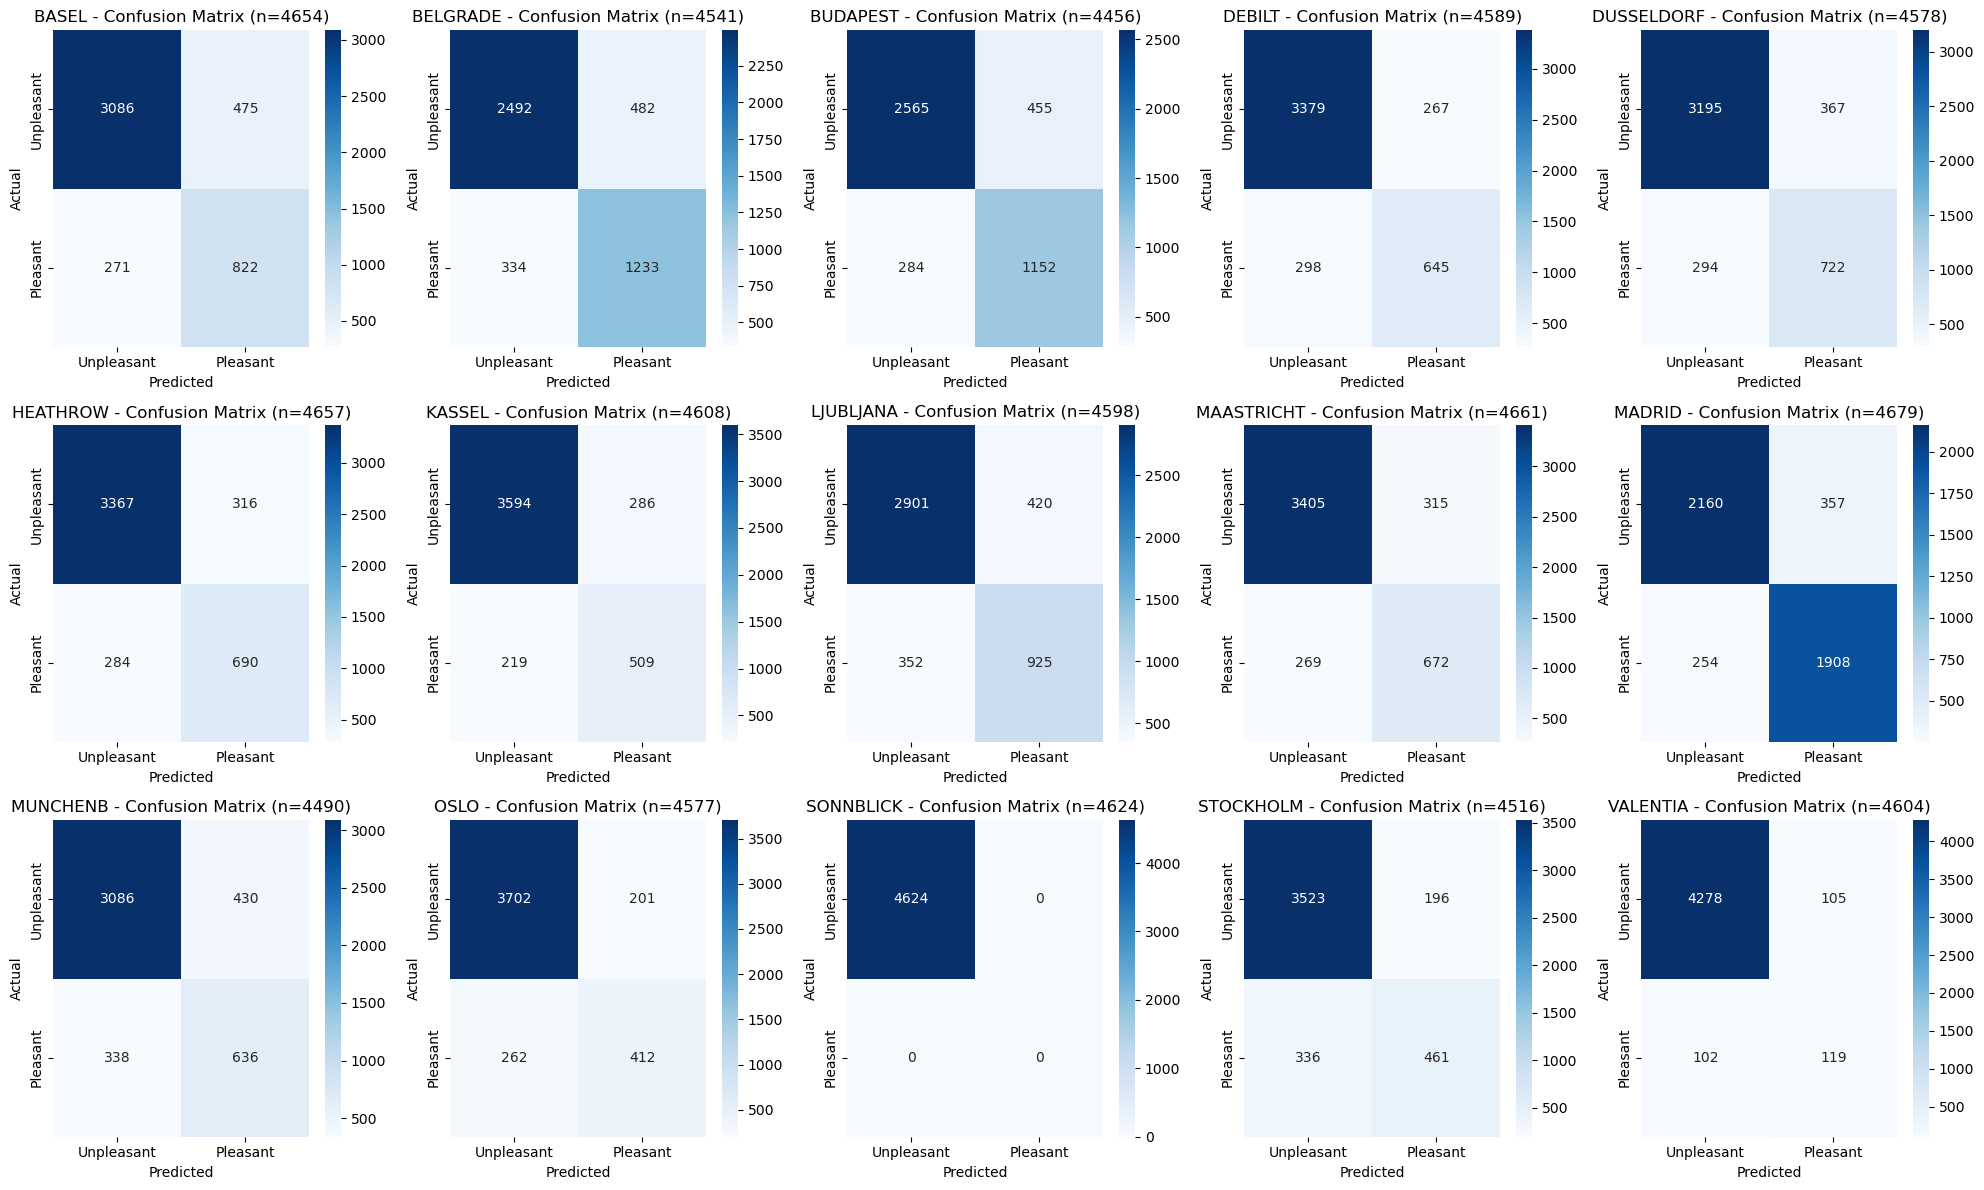

In [58]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
plot_city_performance_corrected(y_test, y_pred, test_meta)